In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import datetime
from itertools import chain
import pytz
from mpl_toolkits.mplot3d import Axes3D
import pickle
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

In [3]:
def process_monitor_log(case_dir, subploting_map, instance_id=0):
    log_path = os.path.join(case_dir, "monitor.log")
    try:
        with open(log_path, "r") as file:
            log_lines = file.readlines()
    except:
        print(f"No monitor log file: {log_path}")
        return None

    ### parsing
    data = {key: {"time": [], "value": []} for key in 
        list(subploting_map["Load"].keys()) + list(subploting_map["Internal"].keys())
    }
    for line in log_lines:
        if "[INFO]" in line: continue

        # [DEBUG] [2024-12-15 20:08:38,597]: ('Load', [{'request_num': 182, 'prefill.....}])
        timestamp = re.findall(r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d{3}', line)[0]
        # time = datetime.datetime.strptime(timestamp, '%Y-%m-%d %H:%M:%S,%f').timestamp()
        dt = datetime.datetime.strptime(timestamp, '%Y-%m-%d %H:%M:%S,%f')
        # timezone = pytz.FixedOffset(-7 * 60)  
        timezone = pytz.FixedOffset(0 * 60)  
        time = timezone.localize(dt).timestamp()

        try:
            log_type, log_contents = eval(line[35:])  # FIX: Eval is dangerous; Based on the log format
        except:
            print(f"Error: unable to parse line: {line}")
            continue

        if instance_id >= len(log_contents):
            continue
        if log_type not in subploting_map:
            continue
        log_content = log_contents[instance_id]  # only 1 ploting instance
        for key in subploting_map[log_type]:
            data[key]["time"].append(time)
            data[key]["value"].append(log_content.get(key, 0))

    return data

In [4]:
def process_result_file(case_dir, result_file):
    warm_up_request_id, warm_end_request_id = 0, 0

    result_path = os.path.join(case_dir, result_file)
    results = []
    total_requests = 0
    try:
        with open(result_path, "r") as file:
            lines = file.readlines()
    except:
        print(f"Error: unable to read result file: {result_path}")
        return 0

    total_requests = len(lines)
    for line in lines:
        record = json.loads(line.strip())
        if (record["request_id"] < warm_up_request_id or 
            record["request_id"] > total_requests - warm_end_request_id):
            continue
        results.append(record)

    return pd.DataFrame(results)

In [5]:
def min_max_normalize(arr, min_val=None, max_val=None):
    if min_val is None:
        min_val = np.min(arr)
    if max_val is None:
        max_val = np.max(arr)
    normalized_arr = (arr - min_val) / (max_val - min_val)
    return normalized_arr

In [6]:
def average_every_n(lst, n=5):
    result = []
    length = len(lst)
    for i in range(0, length, n):
        chunk = lst[i:min(i + n, length)]
        average = sum(chunk) / len(chunk)
        result.append(average)
    return result

In [7]:
def get_data(case_ids):
    all_metrics = [{} for _ in case_ids]
    max_value = [{} for _ in range(len(case_ids))]
    min_value = [{} for _ in range(len(case_ids))]

    for case_idx, case_id in enumerate(case_ids):
        case_dir = f"./case_{case_id}"
        print(case_dir)
        if not os.path.exists(case_dir):
            return 0

        ### Read results
        files = os.listdir(case_dir)
        result_files = [f for f in files if f.startswith("result") and f.endswith(".json")]
        if len(result_files) != 1: 
            print(f"Error: found {len(result_files)} result file in case {case_id}")
            return 0

        df = process_result_file(case_dir, result_files[-1])
        if 'TTFT' not in df.columns:
            print(f"Error: unable to find TTFT in case {case_id}, no successful finished requests")
            return 0

        with open(os.path.join(case_dir, "config.json"), "r") as file:
            config = json.load(file)
        scheduler_config = config["scheduler_config"]
        num_instances = scheduler_config["num_instances"]
        all_metrics[case_idx]["configurations"] = {
            "num_instances": num_instances,
            "qps": config["request_config"]["qps"],
            "policy": scheduler_config["scheduler_policy"]
        }

        ### Preprocessing
        # Standardize timestamp
        timestamp_base = df["record_time"].values[0]
        df["record_time"] = df["record_time"] - timestamp_base

        # Filter out failed requests
        # status=200 / expection / dummyReq
        df_latency = df.dropna(subset=['TTFT', 'latency', 'record_time', 'TBPT']).copy()
        df_latency["latency_normalized"] = df_latency["latency"] / df_latency["generated_tokens"]

        ### Ploting timeline per instance
        print(f"Timestamp base: {timestamp_base}")
        
        subploting_map = {
            "Load": {
                "incoming_prefill_tokens": 0,
            },
            "Internal": {
                "vllm:gpu_cache_usage_perc": 1,
            }
        }

            
        for instance_id in range(num_instances):
            monitor_data = process_monitor_log(case_dir, subploting_map, instance_id)
            if monitor_data is None: continue

            for metric_name, subplot_id in chain(subploting_map["Load"].items(), subploting_map["Internal"].items()):
                batch = np.full_like(monitor_data[metric_name]["time"] - timestamp_base, instance_id + 1)
                if metric_name not in all_metrics[case_idx]:
                    all_metrics[case_idx][metric_name] = []
                
                timestamp = np.array(monitor_data[metric_name]["time"] - timestamp_base)
                data = np.array(monitor_data[metric_name]["value"])

                # average per 1/1.0 s
                n = 1.0
                bins = np.floor(timestamp * n).astype(int)
                smoothed_timestamp = np.unique(bins)
                smoothed_data = np.array([
                    np.mean(data[bins == b]) for b in smoothed_timestamp
                ])
                batch = np.full_like(smoothed_timestamp.astype(float) / n, instance_id + 1)

                all_metrics[case_idx][metric_name].append((
                    smoothed_timestamp.astype(float) / n, 
                    batch, 
                    smoothed_data))
                max_value[case_idx][metric_name] = max(max_value[case_idx].get(metric_name, 0), np.max(smoothed_data))
                min_value[case_idx][metric_name] = min(min_value[case_idx].get(metric_name, 1e9), np.min(smoothed_data))

            df_latency_i = df_latency[df_latency["instance_id"] == instance_id]

            # average per 1/1.0 s
            n = 1.0
            bins = np.floor(df_latency_i["record_time"] * n).astype(int)
            latency_normalized_smoothed_time = np.unique(bins)
            latency_normalized_smoothed_data = np.array([
                np.mean(df_latency_i["latency_normalized"][bins == b]) for b in latency_normalized_smoothed_time
            ])
            # latency_normalized_smoothed_data = min_max_normalize(latency_normalized_smoothed_data)
            batch = np.full_like(latency_normalized_smoothed_time.astype(float) / n, instance_id + 1)
            max_value[case_idx]["normalized_latency"] = max(max_value[case_idx].get("normalized_latency", 0), np.max(latency_normalized_smoothed_data))
            min_value[case_idx]["normalized_latency"] = min(min_value[case_idx].get("normalized_latency", 1e9), np.min(latency_normalized_smoothed_data))
            if "normalized_latency" not in all_metrics[case_idx]:
                all_metrics[case_idx]["normalized_latency"] = []
            all_metrics[case_idx]["normalized_latency"].append((
                latency_normalized_smoothed_time.astype(float) / n, 
                batch, 
                latency_normalized_smoothed_data))

    return all_metrics, max_value, min_value

In [8]:
all_metrics, max_value, min_value = get_data(case_ids=[1, 2])
print(max_value)
print(min_value)

./case_1
Timestamp base: 1737782226.0698214
No monitor log file: ./case_1/monitor.log
No monitor log file: ./case_1/monitor.log
No monitor log file: ./case_1/monitor.log
No monitor log file: ./case_1/monitor.log
./case_2
Timestamp base: 1737786336.4574685
No monitor log file: ./case_2/monitor.log
No monitor log file: ./case_2/monitor.log
No monitor log file: ./case_2/monitor.log
No monitor log file: ./case_2/monitor.log
[{}, {}]
[{}, {}]


In [9]:
def interpolation_case(all_metrics_case):
    # Get min/max timestamp among all metrics
    min_timestamp, max_timestamp = 1e9, -1e9
    for metric in all_metrics_case.keys():
        if metric == "configurations": continue
        for instance in range(len(all_metrics_case[metric])):
            min_timestamp = min(min_timestamp, all_metrics_case[metric][instance][0][0])
            max_timestamp = max(max_timestamp, all_metrics_case[metric][instance][0][-1])

    print(f"Min timestamp: {min_timestamp}, Max timestamp: {max_timestamp}")
    final_timestamp = np.arange(min_timestamp.astype(int), max_timestamp.astype(int), 1)

    # Interpolation at final_timestamp
    for metric in all_metrics_case.keys():
        if metric == "configurations": continue
        for instance in range(len(all_metrics_case[metric])):
            time, batch, data = all_metrics_case[metric][instance]
            print(f"Metric: {metric}, Instance: {instance}, #Time: {len(time)}, #Data: {len(data)}")
            interpolated_data = np.interp(final_timestamp, time, data)
            interpolated_batch = np.full_like(final_timestamp, instance + 1)
            all_metrics_case[metric][instance] = (final_timestamp, interpolated_batch, interpolated_data)
            print(f"Interpolated Metric: {metric}, Instance: {instance}, #Time: {len(final_timestamp)}, #Data: {len(interpolated_data)}")

    return all_metrics_case
              
        
for all_metrics_case in all_metrics:
    all_metrics_case = interpolation_case(all_metrics_case)  # overwrite

Min timestamp: 1000000000.0, Max timestamp: -1000000000.0


AttributeError: 'float' object has no attribute 'astype'

In [9]:
print(len(all_metrics)) # number of cases
print(len(all_metrics[0])) # number of metrics

print("\ncase 0: number of data points")
all_metrics_case = all_metrics[0]
for k in all_metrics_case.keys():
    if k == "configurations": continue
    print(k, len(all_metrics_case[k])) # number of instances
    print(len(all_metrics_case[k][0][0]), len(all_metrics_case[k][0][1]), len(all_metrics_case[k][0][2])) # number of data points

print("\ncase 1: number of data points")
all_metrics_case = all_metrics[1]
for k in all_metrics_case.keys():
    if k == "configurations": continue
    print(k, len(all_metrics_case[k])) # number of instances
    print(len(all_metrics_case[k][0][0]), len(all_metrics_case[k][0][1]), len(all_metrics_case[k][0][2])) # number of data points


with open("all_metrics.pkl", "wb") as file:
    pickle.dump(all_metrics, file)

2
4

case 0: number of data points
incoming_prefill_tokens 4
339 339 339
vllm:gpu_cache_usage_perc 4
339 339 339
normalized_latency 4
339 339 339

case 1: number of data points
incoming_prefill_tokens 4
344 344 344
vllm:gpu_cache_usage_perc 4
344 344 344
normalized_latency 4
344 344 344


Instance num:  4
case_num: 2, instance_num: 4, metric_num: 3


/var/folders/jc/bdcjm0w14kg95rz2vvmfjt9m0000gn/T/ipykernel_68654/1603645126.py:11: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0, hspace=0)


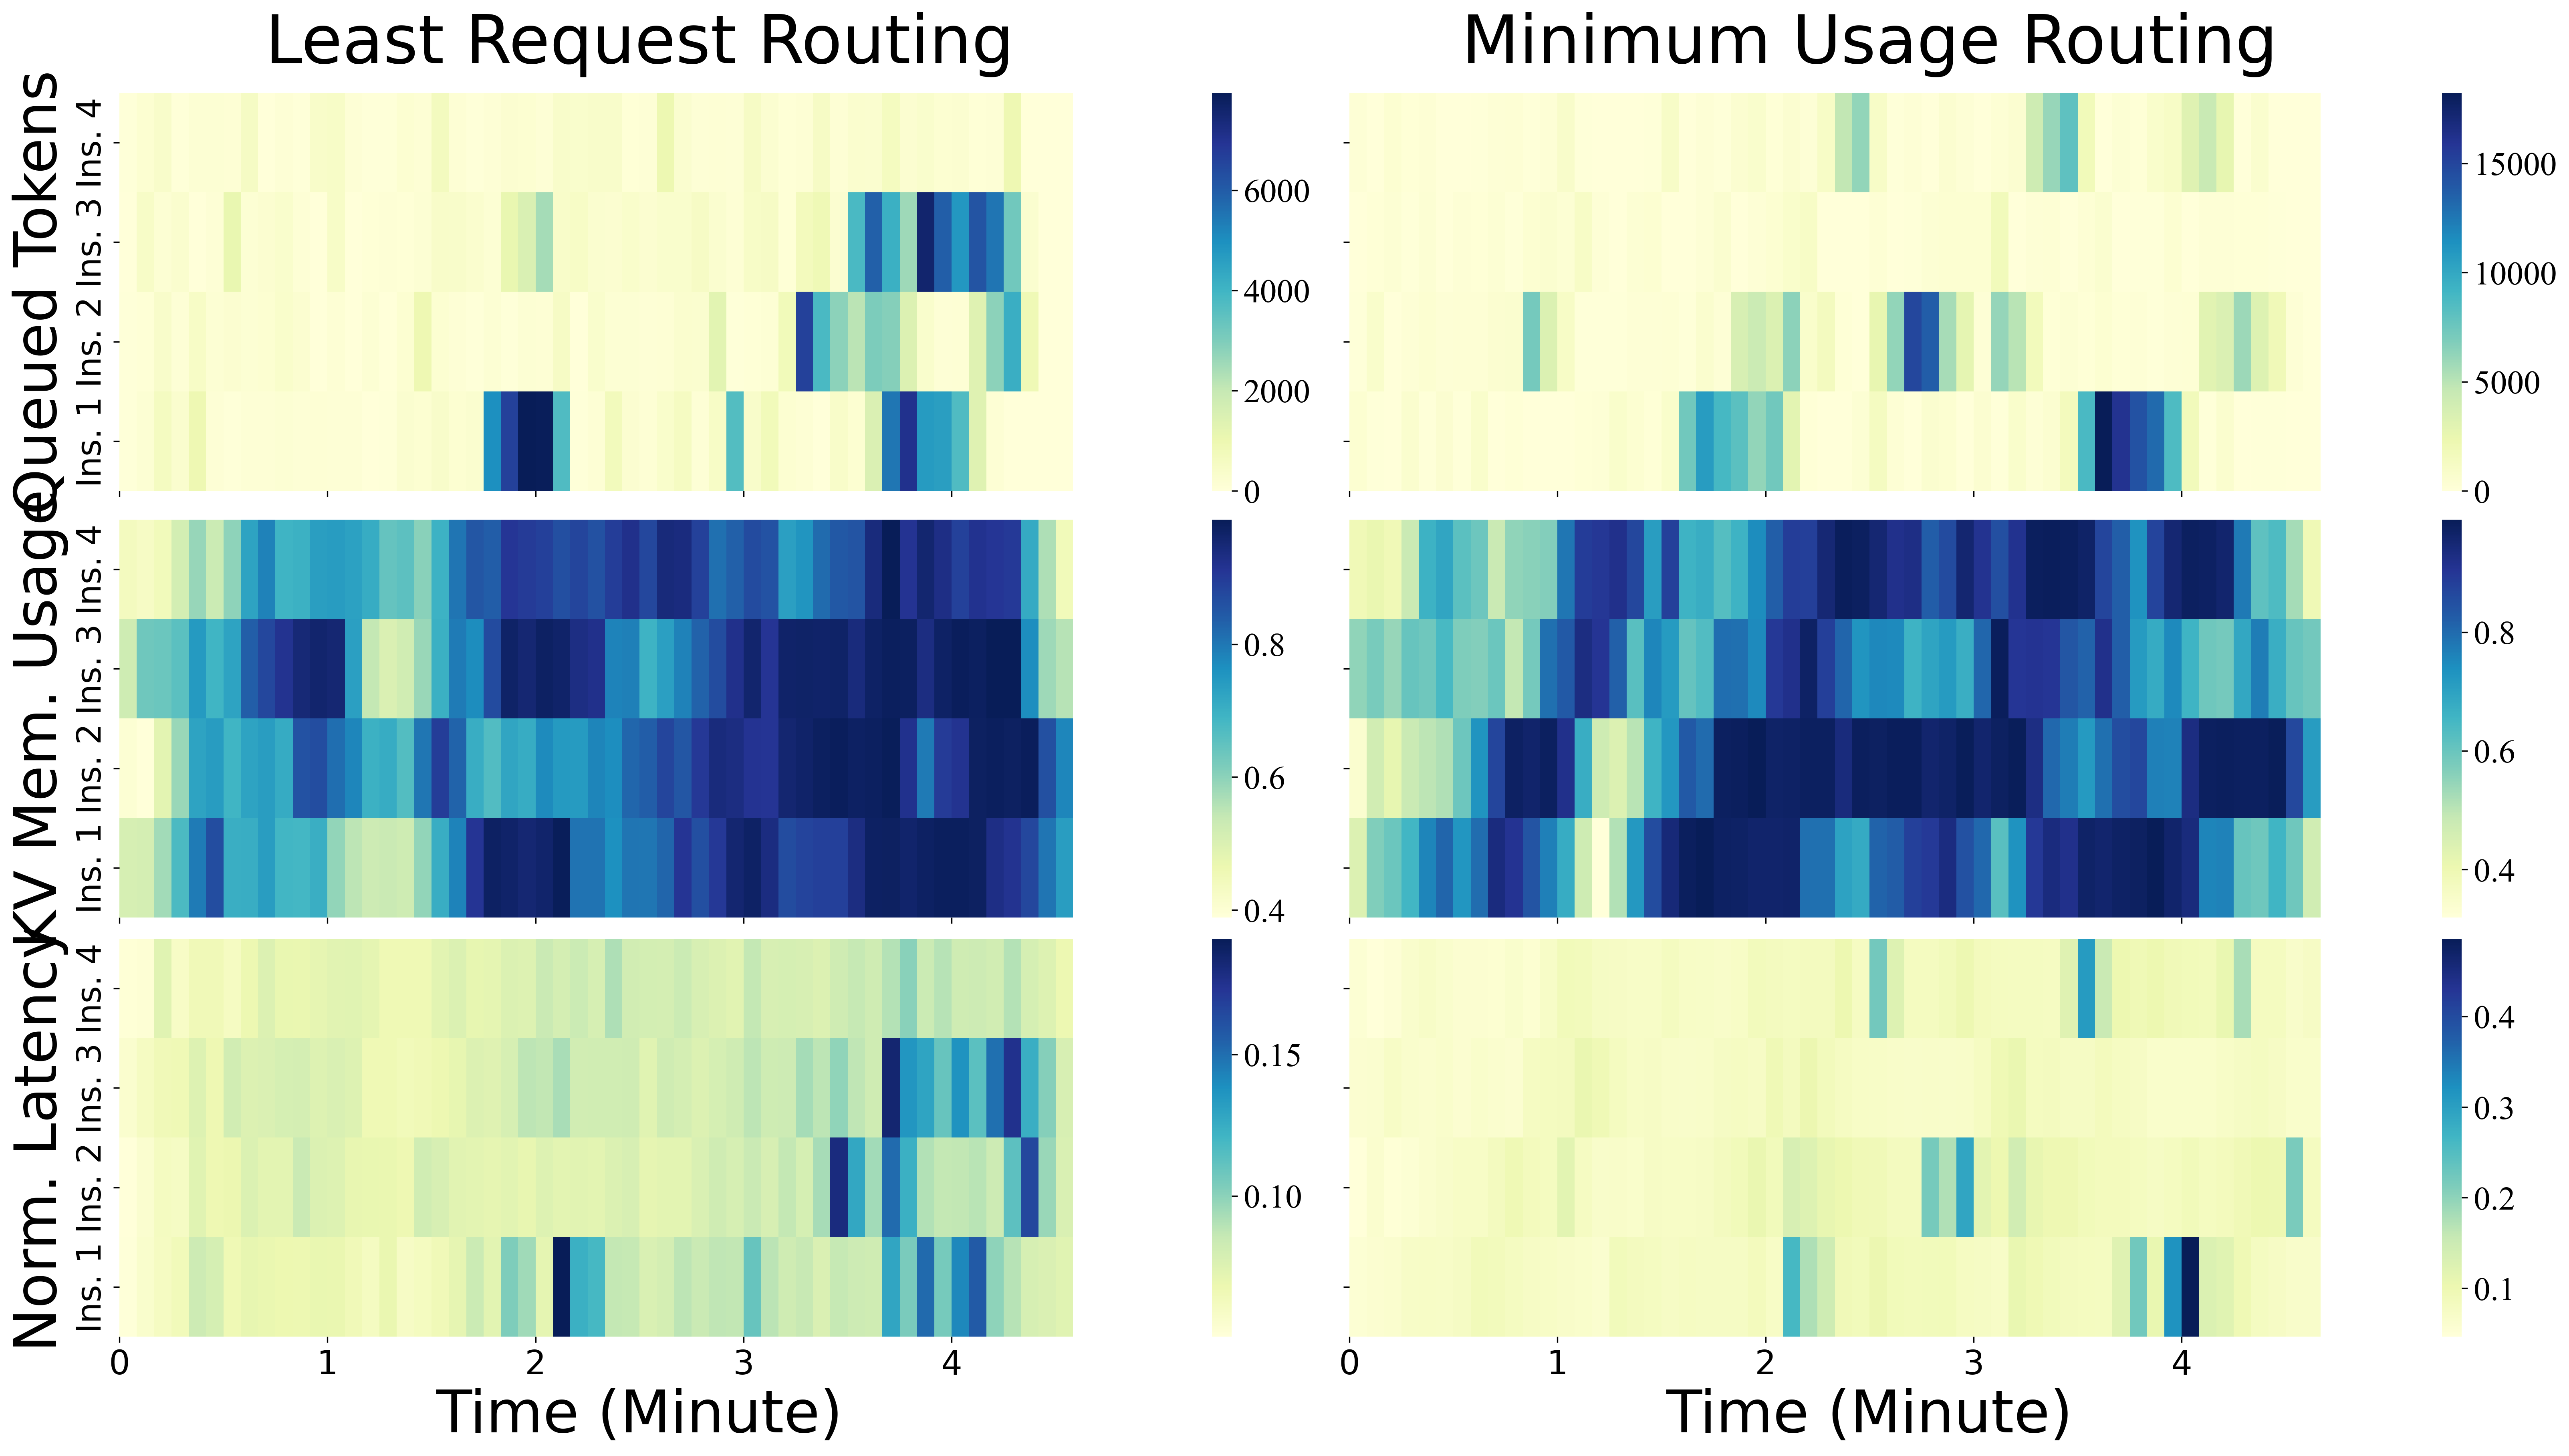

In [10]:
def plot_figures(all_metrics, min_value, max_value, step=5):
    case_num = len(all_metrics)
    metric_num = len(all_metrics[0]) - 1
    instance_num = len(all_metrics[0]["normalized_latency"])
    print("Instance num: ", instance_num)
    print(f"case_num: {case_num}, instance_num: {instance_num}, metric_num: {metric_num}")
    
    row, col = metric_num, case_num
    scale = 2.66
    fig, axes = plt.subplots(nrows=row, ncols=col, figsize=(scale * 4 * col, 4 * row), dpi=300, constrained_layout=True)
    fig.subplots_adjust(wspace=0, hspace=0)

    # fig.tight_layout()
    plt.rcParams.update({'font.size': 20, "font.family": 'Times New Roman'})
    map_title = {
        "incoming_prefill_tokens": "Queued Tokens",
        "vllm:gpu_cache_usage_perc": "KV Mem. Usage",
        "normalized_latency": "Norm. Latency"
    }
    titles = ["Least Request Routing", "Minimum Usage Routing"]
    max_time = 0

    # colors = ["#f6c6af", "#b8b9d2", "#b5d4be", "#afd4e3"]
    colors = ["#55B7E6", "#193E8F", "#7F318D", "#F09739"]
    # colors = ["#55B7E6", "#193E8F", "#E53528", "#F09739"]

    for case_id, case_metrics in enumerate(all_metrics):
        keys_without_configurations = [key for key in case_metrics.keys() if key != "configurations"]
        for metric_id, metric_name in enumerate(keys_without_configurations):
            ax = axes[metric_id, case_id]
            data = []
            for instance_id in range(instance_num - 1, -1, -1):
                time, batch, value = case_metrics[metric_name][instance_id]
                # if metric_name == "normalized_latency":
                    # value = min_max_normalize(value, min_value[case_id][metric_name], max_value[case_id][metric_name])
                value = average_every_n(value, step)
                value = value[int(len(value) * 0.1):int(len(value) * 0.9)]
                data.append(value)
            sns.heatmap(data, fmt="e", cmap='YlGnBu', ax=ax)
 
            if case_id == 0:
                # ax.set_ylabel("Instances", fontsize=30)
                ax.set_yticklabels([f"Ins. {i + 1}" for i in range(instance_num)][::-1], fontsize=20)
            else:
                ax.set_yticklabels([])
            
            step_per_min = 60 // step
            if metric_id == metric_num - 1:
                ax.set_xlabel("Time (Minute)", fontsize=35)
                ax.set_xlim(0, (len(value) + step_per_min - 1) // step_per_min * step_per_min)
                ax.set_xticks(np.arange(0, len(value), step_per_min))
                ax.set_xticklabels([f"{i//step_per_min}" for i in range(0, len(value), step_per_min)], fontsize=20)
            else:
                ax.set_xlim(0, (len(value) + step_per_min - 1) // step_per_min * step_per_min)
                ax.set_xticks(np.arange(0, len(value), step_per_min))
                ax.set_xticklabels([])
            if case_id == 0:
                ax.set_ylabel(map_title[metric_name], fontsize=35, va='bottom')
                # ax.yaxis.set_label_position('right')
                # ax.yaxis.labelpad = 100
            if metric_id == 0:
                ax.set_title(titles[case_id], fontsize=40, y=1.05)


    fig.savefig("motivation_load-balance.pdf", bbox_inches="tight", dpi=200)


with open("all_metrics.pkl", "rb") as file:
    all_metrics = pickle.load(file)
plot_figures(all_metrics, min_value, max_value)